# 01. GeN-Foam + Cantera -> вода у ТВЭЛа -> пар -> химия

Версия расчета: `zircaloy-v1`. Тепловая физика ТВЭЛа берется из реального короткого прогона GeN-Foam/foamForNuclear: `data/genfoam/near_wall_steam_layer/thermal_timeseries.csv`. Python здесь не пересчитывает теплоперенос в топливе и оболочке: он задает локальный водный контрольный объем у наружной стенки, интегрирует поток от оболочки к воде/пару и передает состояние пара в Cantera.

In [1]:
from pathlib import Path
import os
import sys

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

import matplotlib.pyplot as plt
import numpy as np

from thesis_modeling.pipeline_export import (
    PIPELINE_VERSION,
    build_notebook_baseline_scenario,
    export_pipeline_artifacts,
    run_scenario,
)
from thesis_modeling.plots import (
    plot_chemistry_temperature_margin,
    plot_energy_balance,
    plot_pin_cross_section,
    plot_temperature_history,
    plot_water_state,
)
from thesis_modeling.reports import build_energy_funnel, build_pipeline_takeaways
from thesis_modeling.scenarios import scenario_summary

## Сценарий и контрольный объем

Все величины нормированы на один метр ТВЭЛа. Сначала явно считаются геометрия тонкого слоя воды у оболочки, его масса, скрытая теплота испарения и теплоемкость сухого пара. Эти числа задают масштаб: диссоциация возможна только после испарения локального слоя и перегрева пара, причем пар не может быть горячее наружной стенки, если нагревается только от ТВЭЛа.


In [2]:
scenario = build_notebook_baseline_scenario()
summary = scenario_summary(scenario)
summary

{'name': 'annular_water_thermolysis',
 'fuel_radius_mm': 4.0,
 'gap_thickness_um': 80.00000000000021,
 'clad_thickness_mm': 0.5999999999999999,
 'pulse_energy_kj_per_m': 250.0,
 'pulse_duration_s': 0.2,
 'water_mass_g_per_m': 1.9317653226923654,
 'water_initial_temperature_k': 620.0,
 'water_saturation_temperature_k': 620.0,
 'chemistry_threshold_k': 3273.15,
 'fuel_melting_temperature_k': 3120.0,
 'clad_melting_temperature_k': 2125.0,
 'clad_limit_temperature_k': 1477.0,
 'genfoam_case_path': '/Users/g.elesin/Desktop/Диплом магистратура/data/genfoam/near_wall_steam_layer',
 'water_layer_thickness_um': 100.0,
 'water_layer_mass_g_per_m': 1.9317653226923654,
 'water_layer_pressure_mpa': 15.5}

In [3]:
geometry = scenario.geometry
layer = scenario.annular_water_layer
assert layer is not None

r_c_m = geometry.clad_outer_radius_m
delta_w_m = layer.thickness_m
area_c_m2_per_m = 2.0 * np.pi * r_c_m
volume_w_m3_per_m = np.pi * ((r_c_m + delta_w_m) ** 2 - r_c_m**2)
mass_w_kg_per_m = scenario.water.mass_kg_per_m
latent_w_kj_per_m = mass_w_kg_per_m * scenario.water.latent_heat_j_kg / 1e3
capacity_v_j_k_m = mass_w_kg_per_m * scenario.water.cp_vapor_j_kg_k
capacity_f_j_k_m = np.pi * geometry.fuel_radius_m**2 * scenario.fuel.volumetric_heat_capacity_j_m3_k
capacity_c_j_k_m = (
    np.pi
    * (geometry.clad_outer_radius_m**2 - geometry.gap_outer_radius_m**2)
    * scenario.clad.volumetric_heat_capacity_j_m3_k
)

{
    "area_clad_m2_per_m": area_c_m2_per_m,
    "water_volume_cm3_per_m": volume_w_m3_per_m * 1e6,
    "water_mass_g_per_m": mass_w_kg_per_m * 1e3,
    "liquid_density_kg_m3": layer.liquid_density_kg_m3,
    "latent_heat_kj_per_m": latent_w_kj_per_m,
    "nominal_liquid_htc_w_m2_k": scenario.water.heat_transfer_coefficient_w_m2_k,
    "temperature_cap_enabled": layer.wall_temperature_cap,
    "vapor_capacity_j_k_m": capacity_v_j_k_m,
    "fuel_capacity_j_k_m": capacity_f_j_k_m,
    "clad_capacity_j_k_m": capacity_c_j_k_m,
}


{'area_clad_m2_per_m': 0.029405307237600466,
 'water_volume_cm3_per_m': 2.971946650295947,
 'water_mass_g_per_m': 1.9317653226923654,
 'liquid_density_kg_m3': 650.0,
 'latent_heat_kj_per_m': 2.124941854961602,
 'nominal_liquid_htc_w_m2_k': 30000.0,
 'temperature_cap_enabled': True,
 'vapor_capacity_j_k_m': 5.02258983900015,
 'fuel_capacity_j_k_m': 150.79644737231007,
 'clad_capacity_j_k_m': 33.0244219745359}

## Минимальные уравнения, которые проверяет ноутбук

GeN-Foam задает историю топлива и наружной оболочки. Локальный водный объем получает энергию только от наружной стенки ТВЭЛа:

\[
\frac{dE_w}{dt}=h_{\mathrm{eff}}(\phi,T_c,T_w) A_c\max(T_c-T_w,0),\qquad
A_c=2\pi R_c.
\]

Численная постобработка не позволяет воде или пару стать горячее стенки:

\[
E_w(t)\le E_w(T_c(t)),\qquad T_w(t)\le T_c(t).
\]

Фазовое состояние считается по кусочному балансу: нагрев жидкости до `T_sat`, испарение через `L_v`, затем перегрев сухого пара. Для химии используется только паровая масса:

\[
m_{H_2}^{eq}=n_{H_2}^{eq}(T_s,p_s)M_{H_2}.
\]

## Загрузка теплового ряда GeN-Foam и химический расчет

Ниже используется внешний `thermal_timeseries.csv`, извлеченный из GeN-Foam-лога. Если файл отсутствует или нарушает контракт колонок, ноутбук должен упасть: fallback в первом прогоне не включен, чтобы не скрывать отсутствие реального теплового ряда.

In [4]:
run = run_scenario(r"\(UO_2\)--Zircaloy, версия 1", scenario)
result = run.result
chemistry = run.chemistry
validation = run.validation
report = run.report

{
    "pipeline_version": PIPELINE_VERSION,
    "thermal_source": result["thermal_source"],
    "thermal_provenance": result["thermal_provenance"],
    "chemistry_method": chemistry["method"],
    "uses_cantera": chemistry["uses_cantera"],
    "validation_ok": validation["ok"],
}

{'pipeline_version': 'zircaloy-v1',
 'thermal_source': 'genfoam',
 'thermal_provenance': '/Users/g.elesin/Desktop/Диплом магистратура/data/genfoam/near_wall_steam_layer/thermal_timeseries.csv',
 'chemistry_method': 'cantera_equilibrium_tp',
 'uses_cantera': True,
 'validation_ok': True}

## Раскрытие временного ряда

Эта ячейка переводит массивы GeN-Foam в физически читаемые числа: максимум температуры, первый момент нарушения ограничения оболочки, момент достижения химического порога, энергия в паре и характерная мощность передачи тепла к пару.

In [5]:
time_s = np.asarray(result["time_s"])
steam_temperature_k = np.asarray(result["water_temperature_k"])
fuel_center_k = np.asarray(result["fuel_center_k"])
clad_outer_k = np.asarray(result["clad_outer_k"])
steam_energy_j_per_m = np.asarray(result["water_energy_j_per_m"])
pulse_energy_j_per_m = np.asarray(result["pulse_energy_j_per_m"])

material_ok = (
    (fuel_center_k < scenario.fuel.melting_temperature_k)
    & (clad_outer_k < scenario.clad.limit_temperature_k)
)
threshold_mask = steam_temperature_k >= scenario.chemistry_threshold_k
positive_pulse = pulse_energy_j_per_m > 0.0
eta_steam = np.divide(
    steam_energy_j_per_m,
    pulse_energy_j_per_m,
    out=np.zeros_like(steam_energy_j_per_m),
    where=positive_pulse,
)
steam_power_w_per_m = np.gradient(steam_energy_j_per_m, time_s)

def first_time(mask):
    return float(time_s[np.flatnonzero(mask)[0]]) if np.any(mask) else np.nan

peak_i = int(np.argmax(steam_temperature_k))
{
    "t_end_s": float(time_s[-1]),
    "max_steam_k": float(steam_temperature_k[peak_i]),
    "time_of_max_steam_s": float(time_s[peak_i]),
    "max_fuel_center_k": float(np.max(fuel_center_k)),
    "max_clad_outer_k": float(np.max(clad_outer_k)),
    "first_clad_limit_s": first_time(clad_outer_k >= scenario.clad.limit_temperature_k),
    "first_chemistry_threshold_s": first_time(threshold_mask),
    "first_threshold_with_material_ok_s": first_time(threshold_mask & material_ok),
    "final_steam_energy_kj_per_m": float(steam_energy_j_per_m[-1] / 1e3),
    "max_eta_steam_percent": float(np.max(eta_steam) * 100.0),
    "max_heat_to_steam_kw_per_m": float(np.max(steam_power_w_per_m) / 1e3),
}

{'t_end_s': 2.99,
 'max_steam_k': 675.7182796713714,
 'time_of_max_steam_s': 0.52846154,
 'max_fuel_center_k': 716.32,
 'max_clad_outer_k': 675.7391,
 'first_clad_limit_s': nan,
 'first_chemistry_threshold_s': nan,
 'first_threshold_with_material_ok_s': nan,
 'final_steam_energy_kj_per_m': 2.4047919202856005,
 'max_eta_steam_percent': 9.08755183287325,
 'max_heat_to_steam_kw_per_m': 113.59439791091565}

## Связь теплового ряда с химией

Cantera считает равновесный состав для каждого состояния пара. Здесь явно сопоставляются температура, молярная доля `H2` и масса равновесного водорода; это уже не энергетическая оценка от полной энергии импульса.

In [6]:
h2_mole_fraction = np.asarray(chemistry["h2_mole_fraction"])
h2_kg_per_m = np.asarray(chemistry["hydrogen_kg_per_m"])
h2_max_kg_per_m = np.asarray(chemistry["max_hydrogen_kg_per_m"])
chem_i = int(np.argmax(h2_kg_per_m))

{
    "peak_h2_g_per_m": float(h2_kg_per_m[chem_i] * 1e3),
    "time_of_peak_h2_s": float(time_s[chem_i]),
    "temperature_at_peak_h2_k": float(steam_temperature_k[chem_i]),
    "peak_h2_mole_fraction": float(h2_mole_fraction[chem_i]),
    "stoichiometric_h2_limit_g_per_m": float(np.max(h2_max_kg_per_m) * 1e3),
    "h2_fraction_of_stoich_percent": float(100.0 * h2_kg_per_m[chem_i] / max(np.max(h2_max_kg_per_m), 1e-30)),
}

{'peak_h2_g_per_m': 7.611284814946713e-13,
 'time_of_peak_h2_s': 0.52846154,
 'temperature_at_peak_h2_k': 675.7182796713714,
 'peak_h2_mole_fraction': 3.5211128820151465e-12,
 'stoichiometric_h2_limit_g_per_m': 0.21616134074569396,
 'h2_fraction_of_stoich_percent': 3.521112882021358e-10}

## Проверка адекватности результата

Проверки ниже не доказывают истинность модели, но ловят типичные ошибки результата: немонотонное время, отрицательную энергию, нефизические температуры, нестыковку энергетического баланса и выход водорода выше стехиометрического предела. Для первого notebook источник обязан быть `genfoam`, а химия обязана идти через Cantera.

In [7]:
adequacy_checks = {
    "source_is_genfoam": result["thermal_source"] == "genfoam",
    "wall_coupled_adapter": result["thermal_adapter"] == "wall_coupled_annular_water",
    "chemistry_is_cantera": chemistry["method"] == "cantera_equilibrium_tp" and chemistry["uses_cantera"],
    "validation_ok": validation["ok"],
    "fuel_hotter_than_clad": float(np.max(fuel_center_k)) > float(np.max(clad_outer_k)),
    "steam_below_threshold_here": float(np.max(steam_temperature_k)) < scenario.chemistry_threshold_k,
    "h2_below_stoichiometric_limit": bool(np.all(h2_kg_per_m <= h2_max_kg_per_m + 1e-15)),
}

assert all(adequacy_checks.values()), adequacy_checks
adequacy_checks


{'source_is_genfoam': True,
 'wall_coupled_adapter': True,
 'chemistry_is_cantera': True,
 'validation_ok': True,
 'fuel_hotter_than_clad': True,
 'steam_below_threshold_here': True,
 'h2_below_stoichiometric_limit': True}

## Графики результата

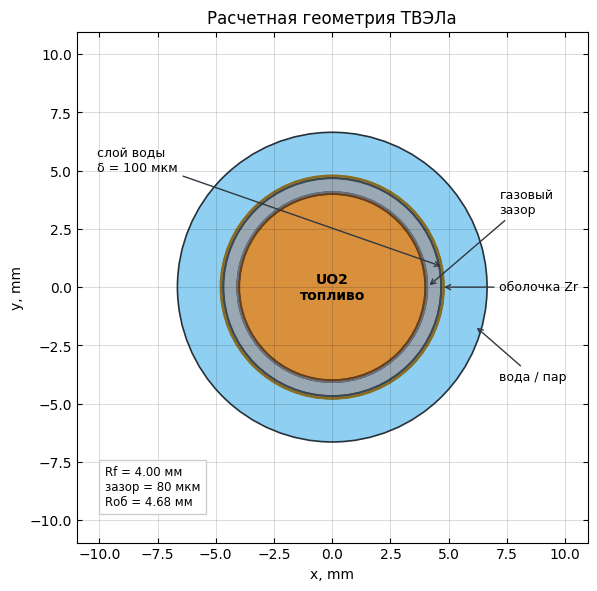

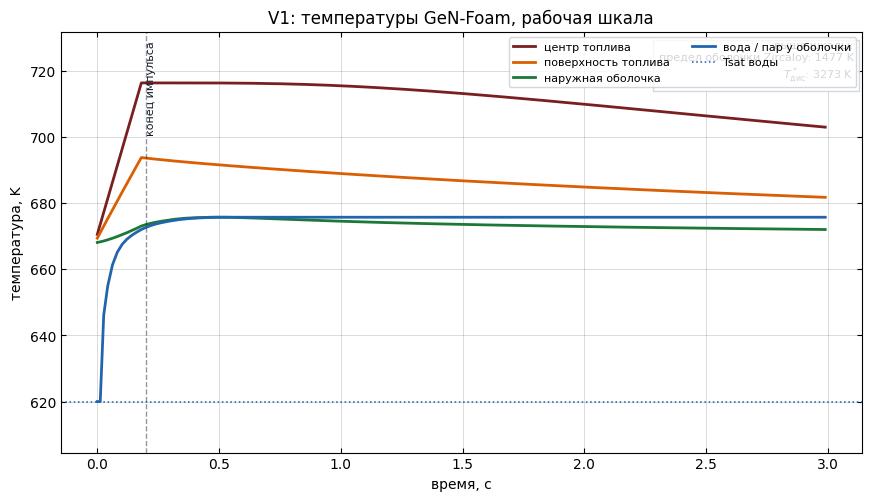

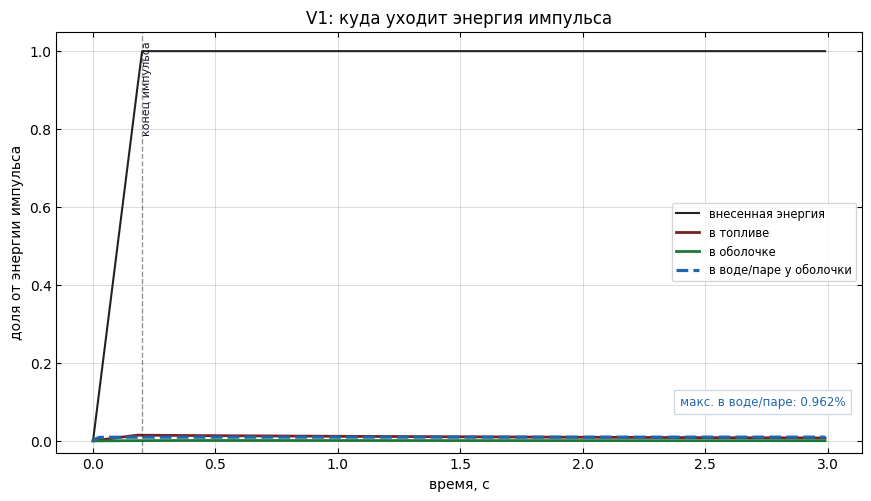

In [8]:
fig, ax = plt.subplots(figsize=(6.8, 5.8), constrained_layout=True)
plot_pin_cross_section(scenario, ax)
plt.show()

fig, ax = plt.subplots(figsize=(8.6, 4.9), constrained_layout=True)
plot_temperature_history(result, ax)
plt.show()

fig, ax = plt.subplots(figsize=(8.6, 4.9), constrained_layout=True)
plot_energy_balance(result, ax)
plt.show()

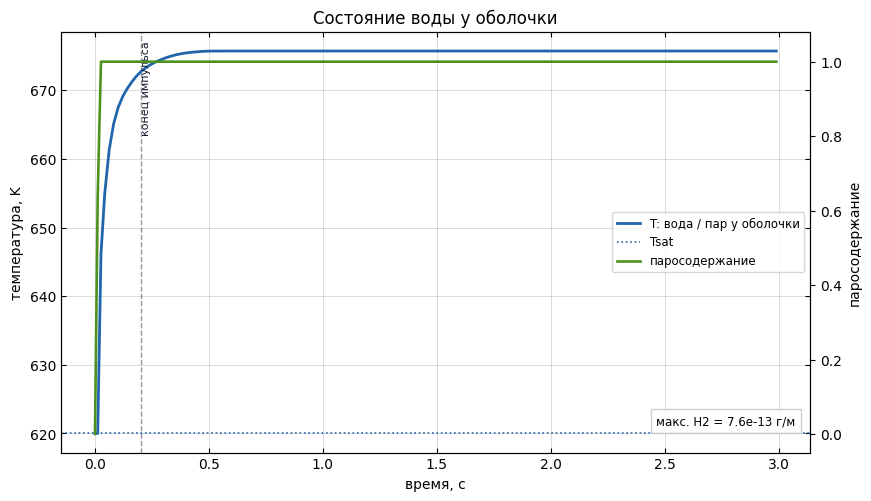

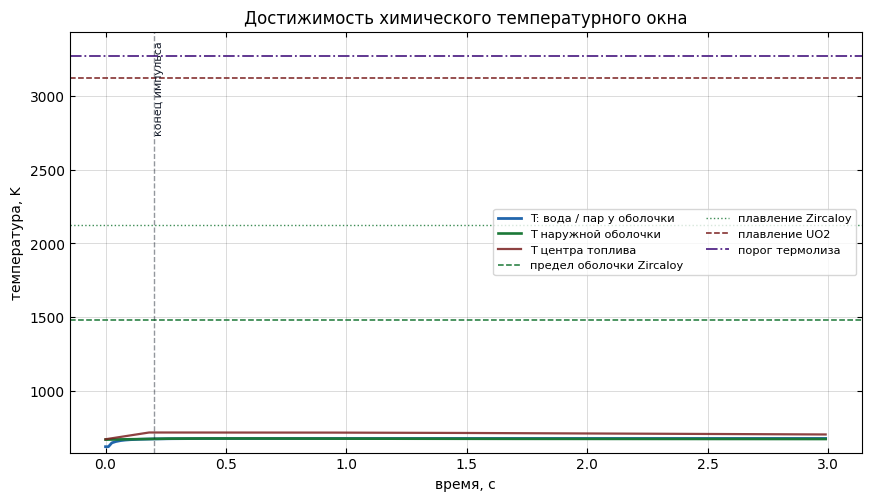

In [9]:
fig, ax = plt.subplots(figsize=(8.6, 4.9), constrained_layout=True)
plot_water_state(result, chemistry, ax)
plt.show()

fig, ax = plt.subplots(figsize=(8.6, 4.9), constrained_layout=True)
plot_chemistry_temperature_margin(result, ax)
plt.show()

## Итоговые метрики

In [10]:
{
    "primary_report": report,
    "energy_funnel": build_energy_funnel(result),
    "takeaways": build_pipeline_takeaways([report]),
}

{'primary_report': {'case': '\\(UO_2\\)--Zircaloy, версия 1',
  'fuel': 'UO2',
  'clad': 'Zircaloy',
  'pulse_kj_per_m': 250.0,
  'layer_thickness_um': 100.0,
  'max_gas_k': 675.7182796713714,
  'max_gas_before_limits_k': 675.7182796713714,
  'max_gas_time_s': 0.52846154,
  'chemistry_threshold_k': 3273.15,
  'target_margin_k': -2597.4317203286287,
  'target_margin_before_limits_k': -2597.4317203286287,
  'max_fuel_k': 716.32,
  'fuel_melting_k': 3120.0,
  'fuel_margin_k': 2403.68,
  'max_clad_k': 675.7391,
  'clad_melting_k': 2125.0,
  'clad_limit_k': 1477.0,
  'clad_margin_k': 1449.2609,
  'clad_limit_margin_k': 801.2609,
  'threshold_reached': False,
  'threshold_time_s': nan,
  'threshold_before_material_limits': False,
  'threshold_before_limits_time_s': nan,
  'below_melting': True,
  'below_temperature_limits': True,
  'energy_to_water_percent': 0.9619167681142402,
  'final_water_energy_kj_per_m': 2.4047919202856005,
  'final_vapor_quality': 1.0,
  'peak_h2_g_per_m': 7.611284814

## Синхронизация с LaTeX

При тестовом запуске можно поставить `SKIP_PIPELINE_EXPORT=1`, чтобы не перезаписывать рисунки. Экспорт первого notebook использует тот же реальный ряд GeN-Foam и не включает fallback.

In [11]:
if os.environ.get("SKIP_PIPELINE_EXPORT") != "1":
    export_pipeline_artifacts(ROOT / "figures")